# Tutorial #3: Projection

# Projecting factors onto single cell and bulk RNA-seq datasets 

In this tutorial, we will project scFO-organize factors on two external datasets:
- 1: A scRNA-seq cohort of 10 studies/>1 million cells/nuclei which were held out from our GBM atlas as validation
- 2: An integrated cohort of over 500 bulk-RNAseq GBM biopsies from 4 studies (TCGA, CGGA, GLASS, Gravendeel) that were deconvolved using CIBERSORTx and our main single cell GBM atlas.

# Import packages

In [1]:
import pandas as pd
import numpy as np
import anndata as ad
import scanpy as sc
import muon as mu
import re
import gseapy as gp
import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import scfo

In [2]:
import scfo

In [3]:
ontology = mu.read_h5mu('scfo_output/scfo_mofa_gbm.h5mu')

# Projection onto single cell data

First, we load and organize our single cell `AnnData` objects. We will project onto each study's dataset separately and concatenate at the end:

In [44]:
adata_proj_dict

{'Schmassmann_2023': AnnData object with n_obs × n_vars = 31051 × 14004
     obs: 'Patient_Study', 'Study', 'Cells vs Nuclei', 'classification',
 'Pombo_2021': AnnData object with n_obs × n_vars = 60790 × 15368
     obs: 'Patient_Study', 'Study', 'Cells vs Nuclei', 'classification',
 'Hei_2025': AnnData object with n_obs × n_vars = 41153 × 13648
     obs: 'Patient_Study', 'Study', 'Cells vs Nuclei', 'classification',
 'Wang_2020': AnnData object with n_obs × n_vars = 13783 × 16670
     obs: 'Patient_Study', 'Study', 'Cells vs Nuclei', 'classification',
 'Darmanis_2017': AnnData object with n_obs × n_vars = 3371 × 20575
     obs: 'Patient_Study', 'Study', 'Cells vs Nuclei', 'classification',
 'Matthewson_2021': AnnData object with n_obs × n_vars = 23118 × 13813
     obs: 'Patient_Study', 'Study', 'Cells vs Nuclei', 'classification',
 'Sonpatki_2026': AnnData object with n_obs × n_vars = 142761 × 29661
     obs: 'Patient_Study', 'Study', 'Cells vs Nuclei', 'classification',
 'GBM_Space':

Now, we can project onto each dataset within a `for-loop`. First let's make sure that `ontology` obs are in the correct format:

In [47]:
cls = ontology.obs["Classification"]

if pd.api.types.is_categorical_dtype(cls):
    if "Unknown" not in cls.cat.categories:
        cls = cls.cat.add_categories(["Unknown"])
    ontology.obs["Classification"] = cls.fillna("Unknown").astype(str)
else:
    ontology.obs["Classification"] = cls.fillna("Unknown").astype(str)

The `project_ontology()` function can be used in cell-type-aware mode, in which factors are only projected onto cells with the corresponding cell type annotation in `annotation_key`. Otherwise, if used in cell-type-agnostic mode, every factor is projected onto every cell.

Here, we've already annotated cells, so we can use cell-type-aware mode. The output scores and p-values are saved in `.obsm` of the input `AnnData` as cells x (factors x cell-types) dataframes, which contain `NaN` for non-tested combinations when run in cell-type-aware mode. We've included a helper function `collapse_projected_ontology_scores()` to condense the output score DataFrame into cells x factors, removing the NaN fillers:

In [52]:
collapsed_dict = {}
for adata_key in tqdm(adata_proj_dict.keys()):
    print('Starting '+adata_key)
    adata_proj_dict[adata_key].obs['classification'] = adata_proj_dict[adata_key].obs['classification'].astype(str)
    scfo.project_ontology(
        adata=adata_proj_dict[adata_key],
        ontology=ontology,
        annotation_key="classification",
        score_key_added="ontology_scores",
        pval_key_added="ontology_pvals",
        method="permutation",
        n_iter=1000,
        inplace=True,
    )

    collapsed = scfo.collapse_projected_ontology_scores(
        adata=adata_proj_dict[adata_key],
        score_key="ontology_scores",
        output_key="ontology_scores_collapsed",
        agg="sum",
        store_sparse=False,
    )

    collapsed_dict[adata_key] = collapsed

  0%|          | 0/9 [00:00<?, ?it/s]

Starting Schmassmann_2023


Permuting Tumor...:   0%|          | 0/1000 [00:00<?, ?it/s]

Permuting T cell...:   0%|          | 0/1000 [00:00<?, ?it/s]

Permuting Mg_TAM...:   0%|          | 0/1000 [00:00<?, ?it/s]

...

Permuting Oligo...:   0%|          | 0/1000 [00:00<?, ?it/s]

Permuting Mg_TAM...:   0%|          | 0/1000 [00:00<?, ?it/s]

Permuting Endothelial...:   0%|          | 0/1000 [00:00<?, ?it/s]

Permuting Non_Mac_Myelocyte...:   0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 9/9 [40:50<00:00, 272.22s/it]


Great! Let's save our projected enrichment scores:

In [ ]:
for study in collapsed_dict.keys():
    collapsed_dict[study].to_csv('val_'+study+'_ontology_enrichment.csv')

# Projection onto bulk RNA-seq data

Next, we'll project our `scfo` object onto deconvolved bulk RNA-seq data. Let's load the output of CIBSERSORTx into an Anndata stratified into pseudo-cell type observations:

In [4]:
all_bulk_exp_ls = []
for cell_type in ['Mo_TAM', 'Mg_TAM', 'Tumor', 'Oligo', 'Neuron', 'T cell', 'Endothelial',]:
    if cell_type in ['T cell']:
        cell_type_load = 'Lymphoid'
    else:
        if cell_type in ['Endothelial']:
            cell_type_load = 'Stromal'
        else:
            cell_type_load = cell_type
        
    decon_counts = pd.read_csv('CIBERSORTx_Job10_output/CIBERSORTxHiRes_Job10_'+cell_type_load+'_Window36.txt', sep = '\t', index_col = 0)
    decon_counts_sub = decon_counts.dropna().T
    decon_counts_sub.index = decon_counts_sub.index.astype(str) + '~' + cell_type
    all_bulk_exp_ls.append(decon_counts_sub)
all_bulk_exp = pd.concat(all_bulk_exp_ls).fillna(0)
all_bulk_exp_adata = ad.AnnData(all_bulk_exp.copy())
all_bulk_exp_adata.obs['patient'] = all_bulk_exp_adata.obs.index.astype(str).str.split('~').str[0]
all_bulk_exp_adata.obs['cell_type'] = all_bulk_exp_adata.obs.index.astype(str).str.split('~').str[1]
all_bulk_exp_adata

AnnData object with n_obs × n_vars = 3990 × 999
    obs: 'patient', 'cell_type'

Projection is now the same as with single cell data above:

In [5]:
all_bulk_exp_adata.obs['cell_type'] = all_bulk_exp_adata.obs['cell_type'].astype(str)
scfo.project_ontology(
    adata=all_bulk_exp_adata,
    ontology=ontology,
    annotation_key="cell_type",
    score_key_added="ontology_scores",
    pval_key_added="ontology_pvals",
    method="permutation",
    n_iter=1000,
    inplace=True,
)

collapsed = scfo.collapse_projected_ontology_scores(
    adata=all_bulk_exp_adata,
    score_key="ontology_scores",
    output_key="ontology_scores_collapsed",
    agg="sum",
    store_sparse=False,
)

Permuting Mo_TAM...:   0%|          | 0/1000 [00:00<?, ?it/s]

Permuting Mg_TAM...:   0%|          | 0/1000 [00:00<?, ?it/s]

Permuting Tumor...:   0%|          | 0/1000 [00:00<?, ?it/s]

Permuting Oligo...:   0%|          | 0/1000 [00:00<?, ?it/s]

Permuting Neuron...:   0%|          | 0/1000 [00:00<?, ?it/s]

Permuting T cell...:   0%|          | 0/1000 [00:00<?, ?it/s]

Permuting Endothelial...:   0%|          | 0/1000 [00:00<?, ?it/s]

Let's convert to wide formatted DataFrame:

In [6]:
collapsed_wide_ls = []
for cell_type in ['Mo_TAM', 'Mg_TAM', 'Tumor', 'Oligo', 'Neuron', 'T cell', 'Endothelial',]:
    collapsed_ct = collapsed.loc[collapsed.index.astype(str).str.contains(cell_type)].copy()
    collapsed_ct.columns = collapsed_ct.columns.astype(str) + '|' + cell_type
    collapsed_ct.index = collapsed_ct.index.astype(str).str.split('~').str[0]
    collapsed_wide_ls.append(collapsed_ct)
collapsed_wide = pd.concat(collapsed_wide_ls, axis = 1)
collapsed_wide

factor,Factor0|Mo_TAM,Factor1|Mo_TAM,Factor10|Mo_TAM,Factor11|Mo_TAM,Factor12|Mo_TAM,Factor13|Mo_TAM,Factor14|Mo_TAM,Factor15|Mo_TAM,Factor16|Mo_TAM,Factor17|Mo_TAM,...,Factor22|Endothelial,Factor23|Endothelial,Factor24|Endothelial,Factor3|Endothelial,Factor4|Endothelial,Factor5|Endothelial,Factor6|Endothelial,Factor7|Endothelial,Factor8|Endothelial,Factor9|Endothelial
0669db2c-5724-4d83-aac7-483708e470c1,2.172108,0.142492,-3.679372,4.545476,-1.274244,-3.759000,0.729580,-1.396947,6.125912,-2.678689,...,3.197110,-0.150271,3.290094,0.713191,13.527076,2.557349,-10.144485,6.478100,-3.039782,1.518013
7aaf54b8-2be8-4b92-91c9-cfc21671dc60,2.876662,-0.876854,-3.350685,5.471870,-1.557641,-3.974654,0.166307,-1.635191,7.338309,-2.461975,...,3.543373,-0.090341,3.055420,1.188467,13.467341,2.596581,-10.679128,6.591559,-3.113157,1.903360
71d11e4c-6fe8-47ba-91a5-6566158614fa,2.981337,-0.942478,-3.287893,5.620138,-1.669198,-4.120736,0.092116,-1.610882,7.471502,-2.526870,...,3.562698,-0.107196,2.611877,1.575987,13.363084,3.221262,-10.925166,6.466803,-3.147485,1.635632
7a4908be-65e5-4008-8eec-becdc9903c74,2.848621,-0.725009,-3.361549,5.459102,-1.610935,-4.043874,0.302532,-1.616996,7.274484,-2.528695,...,4.396177,0.336504,2.820133,1.098236,11.965180,3.596582,-11.509999,7.833582,-3.879203,1.837125
917fa61d-4556-42a0-bc3a-449ef1b29886,2.823185,-0.725172,-3.455388,5.281976,-1.294938,-4.065679,0.061704,-1.902833,7.193763,-2.331904,...,2.394377,-0.421554,3.288712,0.370157,14.053487,1.878376,-9.217755,5.779663,-2.546208,1.408494
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-06-0210,3.097283,-1.117757,-3.035786,5.623170,-1.447609,-4.168631,0.062674,-1.868085,7.625820,-2.368351,...,3.572610,0.012131,3.098696,0.808377,12.929359,2.710101,-10.626691,6.994671,-3.322040,1.717301
GLSS-LU-00C4,2.728815,-0.599737,-3.124716,5.327483,-1.563586,-3.989565,0.602415,-1.522357,7.099806,-2.668964,...,2.514262,-0.455406,3.596589,0.090527,13.642645,1.914778,-8.904546,6.361337,-2.815524,1.352265
GLSS-19-0266,2.656175,-0.529661,-3.303150,5.077674,-1.410836,-3.914978,0.531121,-1.563888,6.923340,-2.549680,...,3.311946,0.110005,3.415349,0.343150,12.736334,2.546367,-10.808949,6.938488,-3.344730,1.695940
GLSS-HF-DF35,2.822588,-0.715804,-3.051261,5.381855,-1.715165,-3.905287,0.690740,-1.383943,7.218084,-2.694013,...,3.981871,0.454342,3.280967,0.226100,11.711479,2.921033,-11.571838,7.828701,-3.842341,1.978918


Perfect! Let's save the projected scores:

In [7]:
collapsed_wide.to_csv('bulk_ontology_enrichment.csv')

# Visualizing projected scFO scores

Let's visualize the projected factor scores from our single-cell validation data at the biopsy-level using a MOFA meta-factorization model. We pre-computed mean scores per biopsy/cell-type:

In [8]:
mean_scores = pd.read_csv('biopsy_factor_scores_mean_val.csv', index_col = 0)
mean_scores

,Factor0|Tumor,Factor1|Tumor,Factor2|Tumor,Factor3|Tumor,Factor4|Tumor,Factor5|Tumor,Factor6|Tumor,Factor7|Tumor,Factor8|Tumor,Factor9|Tumor,...,Factor15|Non_T_Lymphocyte,Factor16|Non_T_Lymphocyte,Factor17|Non_T_Lymphocyte,Factor18|Non_T_Lymphocyte,Factor19|Non_T_Lymphocyte,Factor20|Non_T_Lymphocyte,Factor21|Non_T_Lymphocyte,Factor22|Non_T_Lymphocyte,Factor23|Non_T_Lymphocyte,Factor24|Non_T_Lymphocyte
Sample_Study,,,,,,,,,,,,,,,,,,,,,
BT_S2|Darmanis_2017,19.127513,10.168638,6.689441,6.846266,6.679026,-10.110478,-12.819589,0.337164,-0.103263,4.918297,...,7.959306,0.897987,2.995550,6.886475,4.621409,-2.529916,8.528514,-8.115689,0.0,0.0
BT_S1|Darmanis_2017,9.501127,6.454459,8.562223,3.168612,9.666555,-12.399767,-10.167533,1.185073,-0.951076,2.716467,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BT_S4|Darmanis_2017,10.483598,12.158025,3.803424,6.389529,6.435870,-10.461222,-12.099162,-0.605054,-1.636021,4.395448,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BT_S6|Darmanis_2017,14.115123,11.324239,7.027336,7.010274,6.479696,-12.772143,-10.868887,0.240261,1.659359,6.089708,...,7.992511,-3.580316,3.484629,6.509459,2.339623,-3.761475,5.383177,-5.516670,0.0,0.0
E10|Matthewson_2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9.766344,-2.136087,1.571757,2.328740,3.848797,-0.389612,3.878322,-3.928498,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AT15_GBM_Space,-5.301488,11.697633,-0.876933,0.865539,-0.599297,-2.925354,-2.899438,0.760271,4.803510,-2.574045,...,2.738668,-0.521524,0.097419,0.516557,2.174755,-0.243953,1.838573,-1.922717,0.0,0.0
AT10_GBM_Space,-6.774889,17.044045,-2.233130,-0.119644,0.572048,-2.429151,-4.074339,0.501983,3.753513,1.453989,...,1.106308,-0.084947,0.101210,0.293673,3.106230,1.021381,2.277382,-2.671022,0.0,0.0
AT7_GBM_Space,3.145665,16.031649,-1.106066,-0.834278,2.345716,-4.067070,3.898924,-0.990160,6.099832,3.287361,...,1.051195,-0.666792,0.435184,0.622772,3.213908,0.684325,2.675629,-2.979471,0.0,0.0


In [9]:
metadata = pd.read_csv('biopsy_metadata_val.csv', index_col = 0)
metadata

,index,Study,Patient,TERT,EGFR_mut,ATRX_mut,1p_19q,RT,Steroids,Chemo,...,MGMT,IDH,Lobe,Laterality,Cells vs Nuclei,Platform/chemistry,Lineage enrichment,Tumor vs Core annotation,edge_v_core,cell_used_in_disc
Sample_Study,,,,,,,,,,,,,,,,,,,,,
BT_S2|Darmanis_2017,1001000173.A2|Darmanis_2017|1001000173.A2,Darmanis_2017,BT_S2,Unk,Unk,Unk,Unk,Unk,Unk,Unk,...,M,Unk,Unk,Unk,cell,Smart-seq2,yes,yes,Unk,No_validation
BT_S1|Darmanis_2017,1001000010.C1|Darmanis_2017|1001000010.C1,Darmanis_2017,BT_S1,Unk,Unk,Unk,Unk,Unk,Unk,Unk,...,M,WT,Unk,Unk,cell,Smart-seq2,yes,yes,Unk,No_validation
BT_S4|Darmanis_2017,1001000229.G10|Darmanis_2017|1001000229.G10,Darmanis_2017,BT_S4,Unk,Unk,Unk,Unk,Unk,Unk,Unk,...,U,WT,Unk,Unk,cell,Smart-seq2,yes,yes,Unk,No_validation
BT_S6|Darmanis_2017,1001000258.E2|Darmanis_2017|1001000258.E2,Darmanis_2017,BT_S6,Unk,Unk,Unk,wt,Unk,Unk,Unk,...,U,WT,Unk,Unk,cell,Smart-seq2,yes,yes,Unk,No_validation
E10|Matthewson_2021,E10_GEX_AAACCTGCAAGAAAGG-1-0|Matthewson_2021|g...,Matthewson_2021,E10,Unk,Unk,Unk,wt,1,0,1,...,U,WT,Unk,Unk,cell,Smart-seq2,yes,no,Unk,No_validation
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AT15_GBM_Space,cellranger-arc201_count_7900ade87e2e0d14aa2c77...,GBM_Space,AT15,Unk,Unk,Unk,Unk,Unk,Unk,Unk,...,Unk,WT,Unk,Unk,nucleus,10x_3,no,no,Unk,No_validation
AT10_GBM_Space,cellranger-arc201_count_9b9f744826edc64cc28819...,GBM_Space,AT10,Unk,Unk,Unk,Unk,Unk,Unk,Unk,...,Unk,WT,Unk,Unk,nucleus,10x_3,no,no,Unk,No_validation
AT7_GBM_Space,cellranger-arc201_count_0de50cb44fc7e5b6bf9322...,GBM_Space,AT7,Unk,Unk,Unk,Unk,Unk,Unk,Unk,...,Unk,WT,Unk,Unk,nucleus,10x_3,no,no,Unk,No_validation


Let's see how these biopsies are structured. First, we'll create a `MuData` object with `obs` = biopsies and modalities as cell types. Let's format our `AnnData` dict:

In [10]:
adata_dict = {}
for cell_type in ontology.obs['Classification'].unique():
    mean_scores_ct = mean_scores[mean_scores.columns[mean_scores.columns.astype(str).str.contains(cell_type)]].copy()
    mean_scores_ct_z = (mean_scores_ct - mean_scores_ct.mean()) / mean_scores_ct.std()
    adata_dict[cell_type] = ad.AnnData(mean_scores_ct_z)
adata_dict

{'Tumor': AnnData object with n_obs × n_vars = 78 × 25,
 'Mo_TAM': AnnData object with n_obs × n_vars = 78 × 25,
 'Mg_TAM': AnnData object with n_obs × n_vars = 78 × 25,
 'T cell': AnnData object with n_obs × n_vars = 78 × 25,
 'Neuron': AnnData object with n_obs × n_vars = 78 × 25,
 'Oligo': AnnData object with n_obs × n_vars = 78 × 25,
 'Pericyte': AnnData object with n_obs × n_vars = 78 × 25,
 'Endothelial': AnnData object with n_obs × n_vars = 78 × 25,
 'Astrocyte': AnnData object with n_obs × n_vars = 78 × 25,
 'Non_T_Lymphocyte': AnnData object with n_obs × n_vars = 78 × 25,
 'Non_Mac_Myelocyte': AnnData object with n_obs × n_vars = 78 × 25}

Let's construct the `MuData` object next:

In [11]:
mean_scores_mdata = mu.MuData(adata_dict)
mean_scores_mdata.obs = metadata.loc[mean_scores_mdata.obs.index].astype(str).copy()
m = mean_scores_mdata.copy()
m.obs = pd.DataFrame(index=m.obs_names)
m.obs.index = m.obs.index.astype(str)
m.obs["Cells vs Nuclei"] = mean_scores_mdata.obs["Cells vs Nuclei"].astype(str).values
m.obs["Study"] = mean_scores_mdata.obs["Study"].astype(str).values
for col in ["index", "level_0"]:
    if col in m.obs.columns:
        m.obs = m.obs.drop(columns=col)
m

MuData object with n_obs × n_vars = 78 × 275
  obs:	'Cells vs Nuclei', 'Study'
  11 modalities
    Tumor:	78 x 25
    Mo_TAM:	78 x 25
    Mg_TAM:	78 x 25
    T cell:	78 x 25
    Neuron:	78 x 25
    Oligo:	78 x 25
    Pericyte:	78 x 25
    Endothelial:	78 x 25
    Astrocyte:	78 x 25
    Non_T_Lymphocyte:	78 x 25
    Non_Mac_Myelocyte:	78 x 25

Now, let's integrate the views using MOFA. We'll set `"Cells vs Nuclei"` as the technical covariate:

In [12]:
mu.tl.mofa(m, groups_label='Cells vs Nuclei', outfile = 'validation_biopsies.hdf5', save_metadata=False,)
meta_mofa_scores = pd.DataFrame(m.obsm['X_mofa'], index=m.obs.index,)
meta_mofa_weights = pd.DataFrame(m.varm['LFs'],index=m.var_names,)
meta_mofa_scores.columns = [f'meta_factor_{i}' for i in range(meta_mofa_scores.shape[1])]
meta_mofa_weights.columns = [f'meta_factor_{i}' for i in range(meta_mofa_weights.shape[1])]


        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
       
 
        
Loaded view='Tumor' group='cell' with N=66 samples and D=25 features...
Loaded view='Tumor' group='nucleus' with N=12 samples and D=25 features...
Loaded view='Mo_TAM' group='cell' with N=66 samples and D=25 features...
Loaded view='Mo_TAM' group='nucleus' with N=12 samples and D=25 features...
Loaded view='Mg_TAM' group='cell' with N=66 samples and D=25 features...
Loaded view=

We can first look at the variance explained per meta-factor/view:

In [13]:
import mofax as mfx
model = mfx.mofa_model("validation_biopsies.hdf5")

all_r2_ls = []
for i in range(0, 10):
    r2 = model.calculate_variance_explained(factors = i)
    r2['index'] = r2.View.astype(str) + '|' + r2.Group.astype(str)
    r2.set_index('index', inplace = True)
    all_r2_ls.append(r2.R2)

all_r2 = pd.concat(all_r2_ls, axis = 1).drop(index = ['Neuron|cell', 'Non_Mac_Myelocyte|nucleus'])
all_r2.columns = [f'meta_factor_{i}' for i in range(all_r2.shape[1])]

<Axes: ylabel='index'>

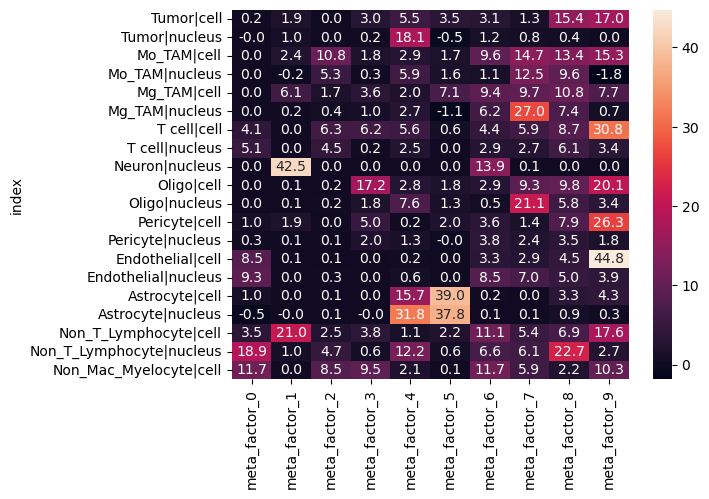

In [15]:
sns.heatmap(all_r2, annot=True, fmt=".1f")

Let's visualize the top few factors. We can do this by making a small `ontology` object for the meta-factors!

In [16]:
ontology_meta = scfo.make_ontology(
    factor_loadings = meta_mofa_weights
)
ontology_meta

MuData object with n_obs × n_vars = 10 × 275
  obs:	'FactorName', 'Classification', 'Number', 'FactorType'
  uns:	'gene_names', 'factor_type', 'modality_names'
  1 modality
    weights:	10 x 275

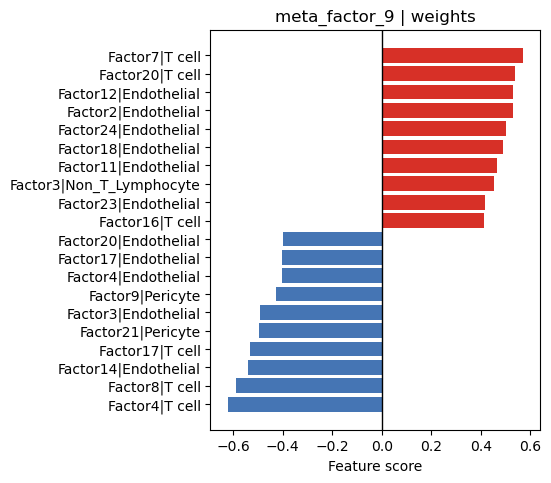

In [17]:
factor = 'meta_factor_9'
mod = 'weights'

fig, ax = scfo.plot_factor_top_features(
    ontology_meta,
    factor=factor,
    modality=mod,
    n_pos=10,
    n_neg = 10,
    figsize = (3.3, 4),
    #path = 'Figures/'+factor+'_'+mod+'.svg'
)

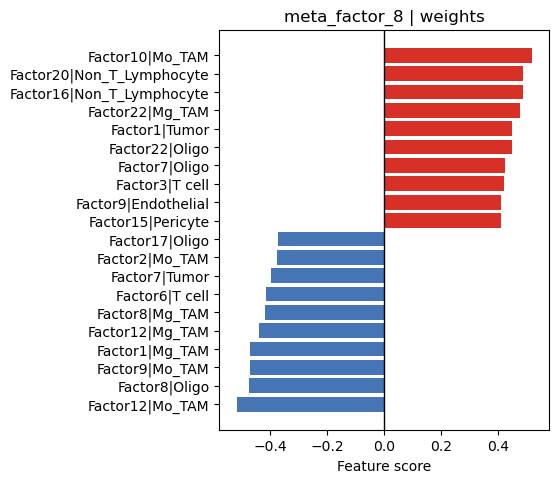

In [18]:
factor = 'meta_factor_8'
mod = 'weights'

fig, ax = scfo.plot_factor_top_features(
    ontology_meta,
    factor=factor,
    modality=mod,
    n_pos=10,
    n_neg = 10,
    figsize = (3.3, 4),
    #path = 'Figures/'+factor+'_'+mod+'.svg'
)

We can now visualize biopsies in meta-MOFA space:

In [19]:
sc.pp.neighbors(m, use_rep = 'X_mofa')
sc.tl.umap(m)

Let's look at meta-factor scores first:

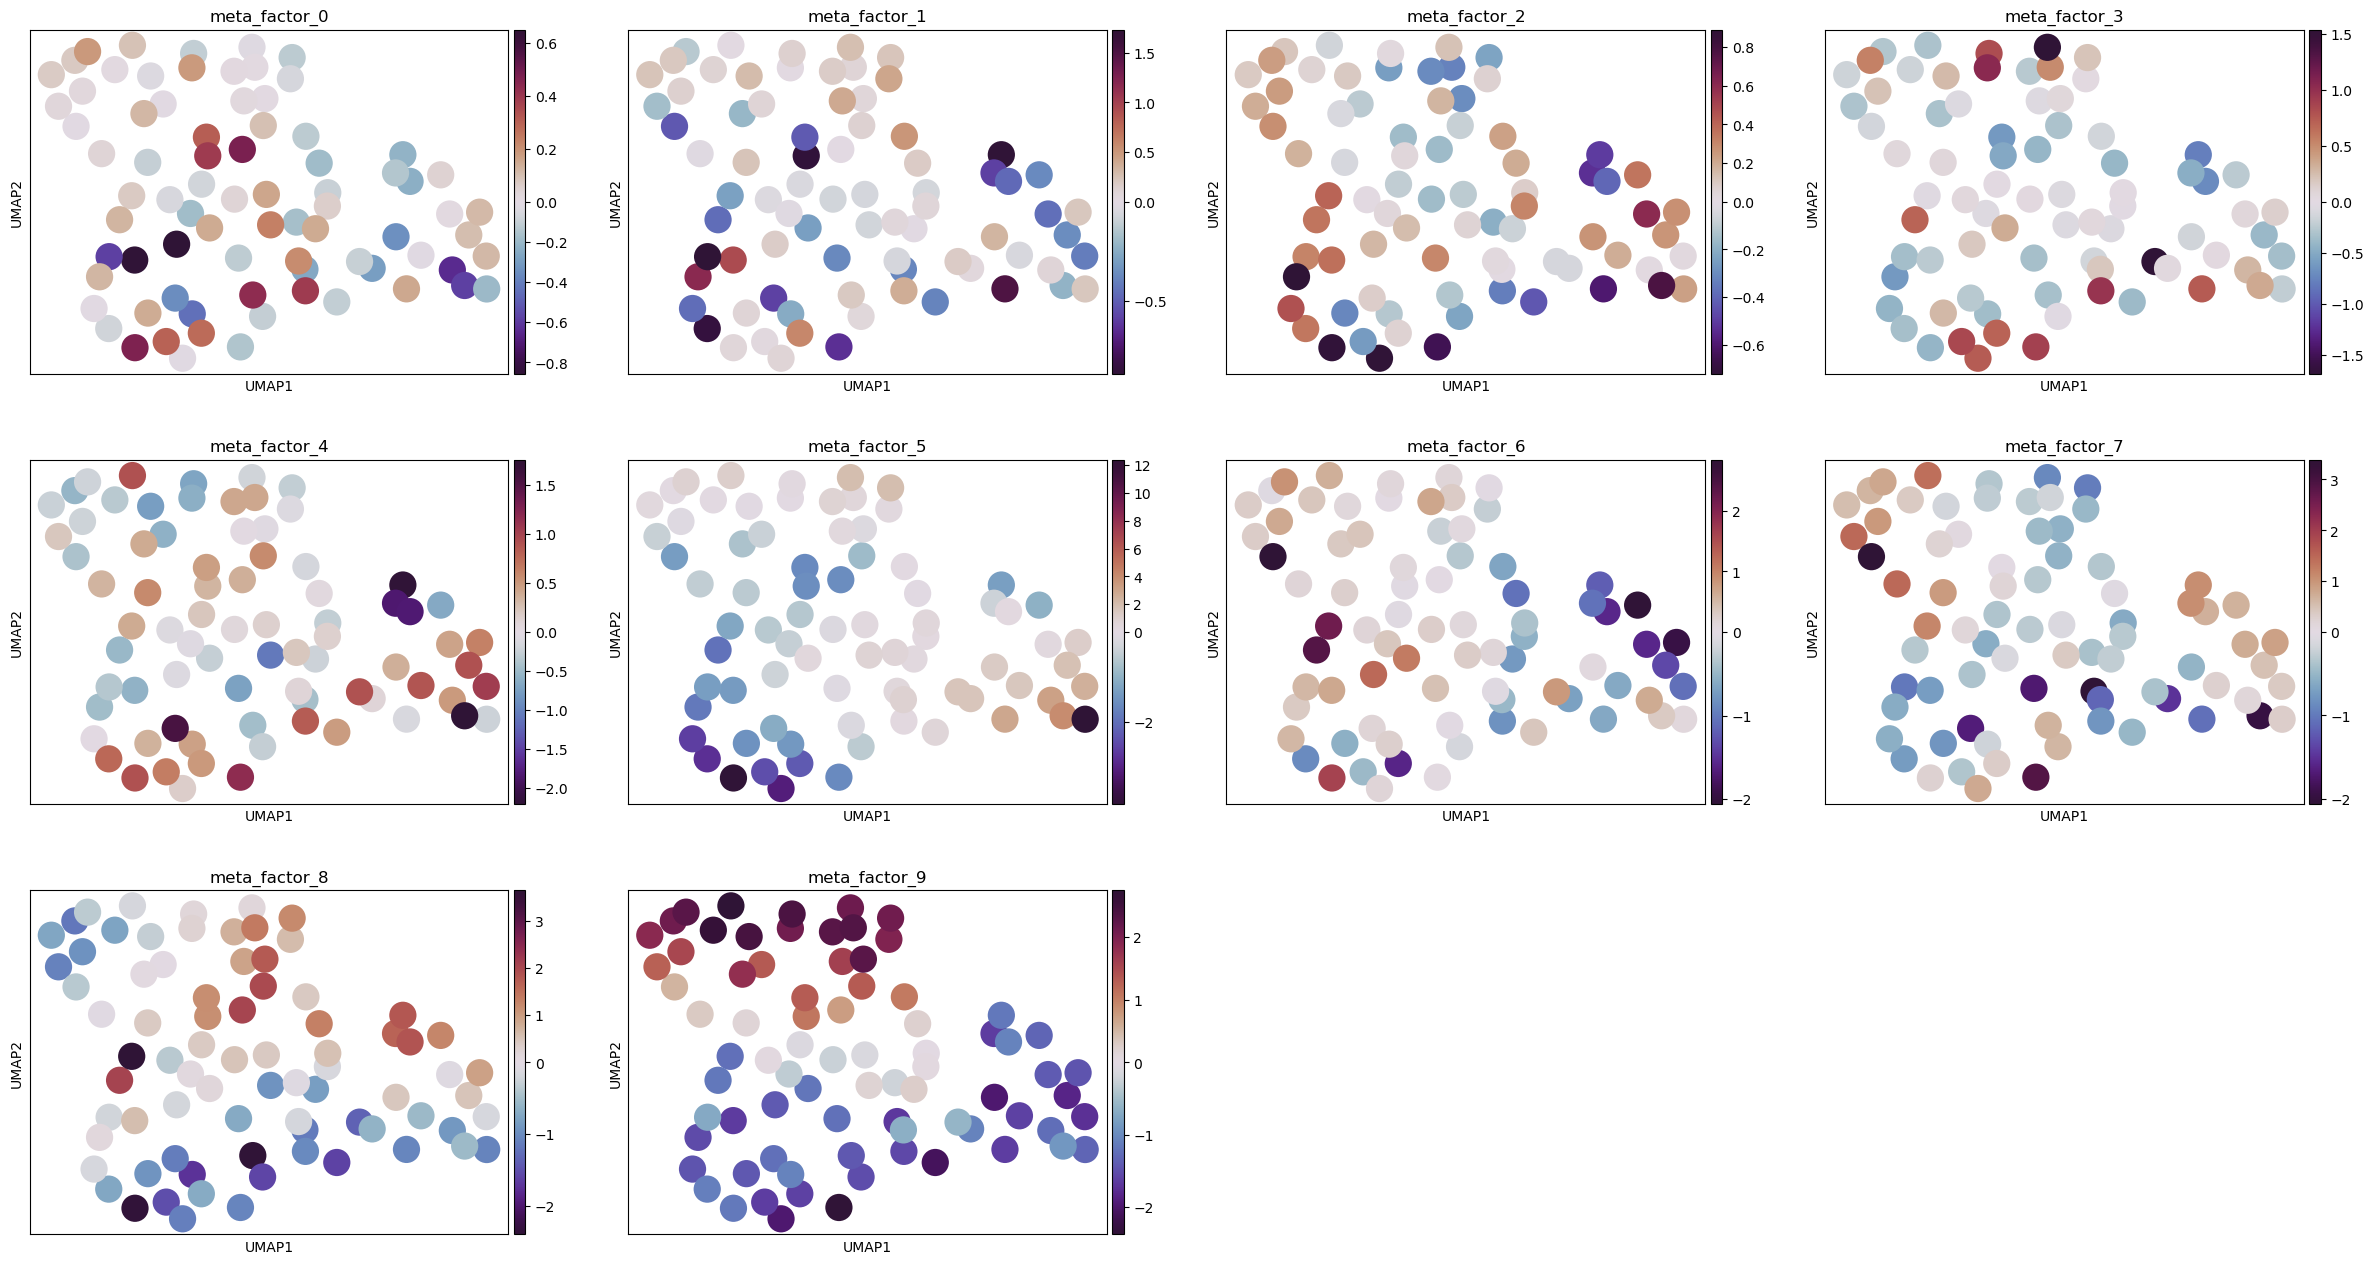

In [20]:
m.obs[meta_mofa_scores.columns] = meta_mofa_scores.copy()
sc.pl.umap(m, color = meta_mofa_scores.columns, vcenter = 0, cmap = 'twilight_shifted')

And then technical covariates:

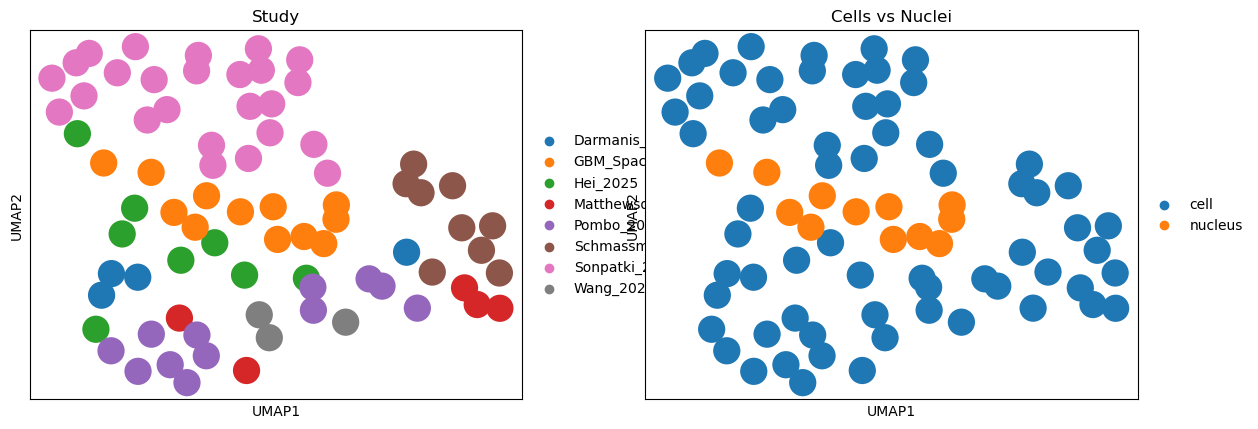

In [21]:
sc.pl.umap(m, color = ['Study', 'Cells vs Nuclei'])

Great! We can use these biopsy-level scores, or the single-cell enrichment scores, for further analysis.

Finally, here is the same analysis with the bulk data:


        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
       
 
        
Loaded view='Mo_TAM' group='group1' with N=570 samples and D=25 features...
Loaded view='Mg_TAM' group='group1' with N=570 samples and D=25 features...
Loaded view='Tumor' group='group1' with N=570 samples and D=25 features...
Loaded view='Oligo' group='group1' with N=570 samples and D=25 features...
Loaded view='Neuron' group='group1' with N=570 samples and D=25 features...
Loa

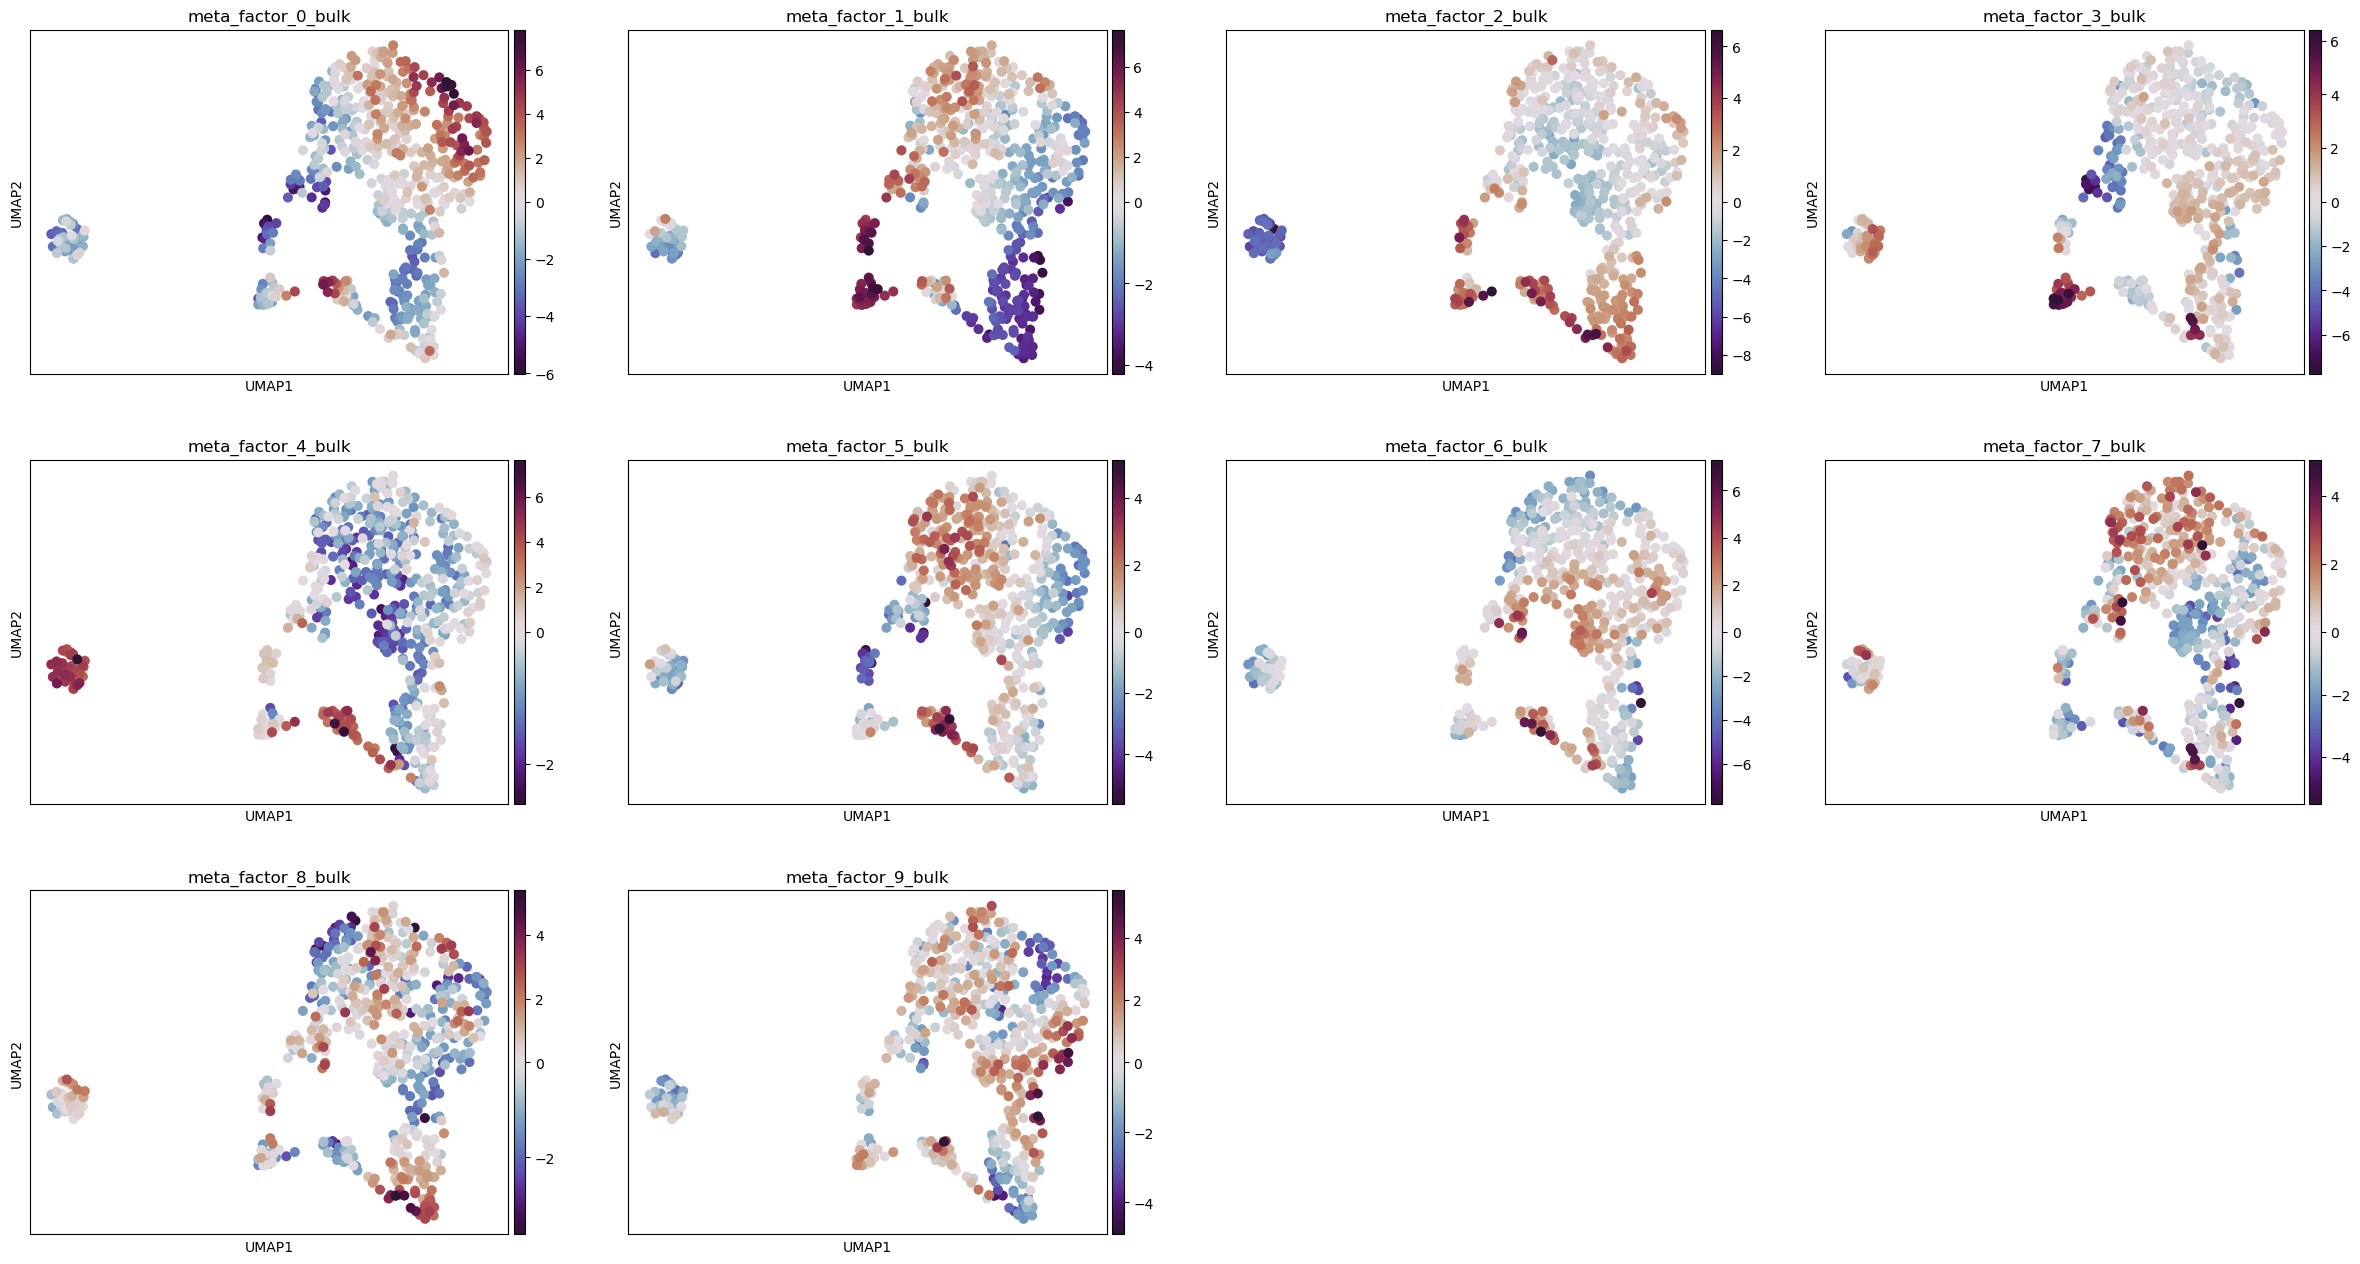

In [22]:
mean_scores = pd.read_csv('bulk_ontology_enrichment.csv', index_col = 0)

adata_dict = {}
for cell_type in ['Mo_TAM', 'Mg_TAM', 'Tumor', 'Oligo', 'Neuron', 'T cell', 'Endothelial',]:
    mean_scores_ct = mean_scores[mean_scores.columns[mean_scores.columns.astype(str).str.contains(cell_type)]].copy()
    mean_scores_ct_z = (mean_scores_ct - mean_scores_ct.mean()) / mean_scores_ct.std()
    adata_dict[cell_type] = ad.AnnData(mean_scores_ct_z)

mean_scores_mdata = mu.MuData(adata_dict)
m = mean_scores_mdata.copy()
m.obs = pd.DataFrame(index=m.obs_names)
m.obs.index = m.obs.index.astype(str)
for col in ["index", "level_0"]:
    if col in m.obs.columns:
        m.obs = m.obs.drop(columns=col)

mu.tl.mofa(m, outfile = 'bulk_biopsies.hdf5', save_metadata=False,)
meta_mofa_scores_bulk = pd.DataFrame(m.obsm['X_mofa'], index=m.obs.index,)
meta_mofa_weights_bulk = pd.DataFrame(m.varm['LFs'],index=m.var_names,)
meta_mofa_scores_bulk.columns = [f'meta_factor_{i}_bulk' for i in range(meta_mofa_scores_bulk.shape[1])]
meta_mofa_weights_bulk.columns = [f'meta_factor_{i}_bulk' for i in range(meta_mofa_weights_bulk.shape[1])]

sc.pp.neighbors(m, use_rep = 'X_mofa')
sc.tl.umap(m)

m.obs[meta_mofa_scores_bulk.columns] = meta_mofa_scores_bulk.copy()
sc.pl.umap(m, color = meta_mofa_scores_bulk.columns, vcenter = 0, cmap = 'twilight_shifted')

Let's see if similar meta-factors arise between the single cell and bulk datasets:

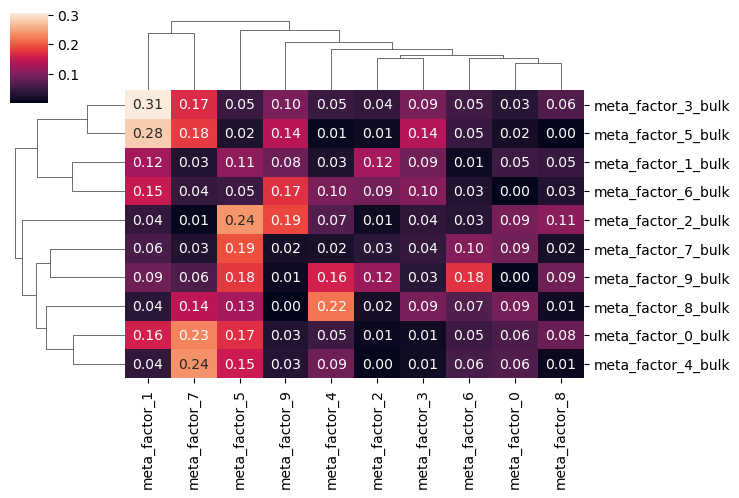

In [23]:
corr_mat = pd.DataFrame(
    index=meta_mofa_weights_bulk.columns,
    columns=meta_mofa_weights.columns,
    dtype=float
)
for col in meta_mofa_weights.columns:
    corr_mat[col] = np.abs(meta_mofa_weights_bulk.corrwith(meta_mofa_weights.loc[meta_mofa_weights_bulk.index, col]))
sns.clustermap(corr_mat, annot=True, fmt=".2f", figsize = (7.5,5))

Cool! Looks like our meta-factorization model picked out some similar trends between the two projected datasets. Now these projected scores can be used to look at transcriptional trends across biopsies.